# LSTM Sentiment Analysis

Sentiment-classification experiments using LSTM-based sequence models, including bidirectional LSTMs, RNN-versus-LSTM comparison, evaluation metrics, confusion-matrix analysis, and an attention extension.

> Portfolio-ready copy of the original completed experiment. Experimental code and saved outputs are preserved; assignment-administration text has been removed.

## Learning Objectives
1. Understand LSTM architecture and gates (forget, input, output)
2. Implement bidirectional and multi-layer LSTMs
3. Apply LSTMs to sentiment classification (many-to-one)
4. Compare LSTM performance with vanilla RNN
5. Analyze attention mechanisms

**TOTAL POINTS:** 100  
**ESTIMATED TIME:** 5-7 hours  
**DATASET:** IMDB Movie Reviews

---


In [1]:
# Setup
import torch
import torch.nn as nn
import torch.optim as optim
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, confusion_matrix
import seaborn as sns
from collections import Counter

torch.manual_seed(42)
np.random.seed(42)

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Using device: {device}")

Using device: cuda


---
## PART 1: Dataset Preparation


In [2]:
def load_imdb_data(sample_size=1000):
    """Load sample IMDB data."""
    positive_reviews = [
        "This movie was absolutely fantastic! Great acting and story.",
        "I loved every minute of it. Highly recommended.",
        "One of the best films I have ever seen. Brilliant!",
        "Amazing cinematography and wonderful performances.",
        "A masterpiece! This is what cinema should be.",
    ] * (sample_size // 2 // 5)

    negative_reviews = [
        "Terrible movie. Waste of time and money.",
        "I hated it. Poor acting and boring plot.",
        "One of the worst films ever made. Awful.",
        "Completely disappointing. Do not watch.",
        "Bad screenplay, terrible direction. Skip this.",
    ] * (sample_size // 2 // 5)

    texts = positive_reviews + negative_reviews
    labels = [1] * len(positive_reviews) + [0] * len(negative_reviews)

    return texts, labels

In [3]:
class IMDBDataset(Dataset):
    """
    IMDB Dataset for sentiment analysis.

    TODO (15 points): Implement IMDB Dataset
    """

    def __init__(self, texts, labels, vocab=None, max_length=256):
        """
        TODO (5 points): Initialize dataset
        Args:
            texts (list[str]): Raw text reviews
            labels (list[int]): Sentiment labels (0 or 1)
            vocab (dict, optional): Existing vocabulary mapping token → index
            max_length (int): Maximum sequence length for padding/truncation
        """
        self.texts = texts
        self.labels = labels
        self.max_length = max_length

        # If no vocab provided, build one
        if vocab is None:
            self.vocab = self.build_vocab()
        else:
            self.vocab = vocab

        # Pre-tokenize and pad all texts
        self.tokenized_texts = [self.tokenize_and_pad(t) for t in self.texts]

    def build_vocab(self, min_freq=2):
        """
        TODO (5 points): Build vocabulary
        Build word → index mapping with min_freq threshold.
        Returns a dict {word: index}.
        """
        from collections import Counter

        # Tokenize all texts
        tokens = []
        for t in self.texts:
            words = t.lower().split()
            tokens.extend(words)

        # Count frequency and apply threshold
        freq = Counter(tokens)
        vocab = {"<PAD>": 0, "<UNK>": 1}
        for word, count in freq.items():
            if count >= min_freq:
                vocab[word] = len(vocab)

        return vocab

    def tokenize_and_pad(self, text):
        """
        TODO (5 points): Tokenize and pad text
        Convert text → list of indices with padding/truncation.
        """
        tokens = text.lower().split()
        ids = [self.vocab.get(tok, self.vocab["<UNK>"]) for tok in tokens]

        # Truncate or pad to max_length
        if len(ids) < self.max_length:
            ids = ids + [self.vocab["<PAD>"]] * (self.max_length - len(ids))
        else:
            ids = ids[: self.max_length]

        return ids

    def __len__(self):
        return len(self.texts)

    def __getitem__(self, idx):
        return {
            "input_ids": torch.LongTensor(self.tokenized_texts[idx]),
            "label": torch.LongTensor([self.labels[idx]]),
        }

In [4]:
# Load and prepare data
texts, labels = load_imdb_data(sample_size=1000)

train_texts, test_texts, train_labels, test_labels = train_test_split(
    texts, labels, test_size=0.2, random_state=42
)
train_texts, val_texts, train_labels, val_labels = train_test_split(
    train_texts, train_labels, test_size=0.2, random_state=42
)

# Create datasets
train_dataset = IMDBDataset(train_texts, train_labels)
val_dataset = IMDBDataset(val_texts, val_labels, vocab=train_dataset.vocab)
test_dataset = IMDBDataset(test_texts, test_labels, vocab=train_dataset.vocab)

# Create dataloaders
train_loader = DataLoader(train_dataset, batch_size=32, shuffle=True)
val_loader = DataLoader(val_dataset, batch_size=32)
test_loader = DataLoader(test_dataset, batch_size=32)

print(f"Train: {len(train_dataset)}, Val: {len(val_dataset)}, Test: {len(test_dataset)}")
print(f"Vocabulary size: {len(train_dataset.vocab)}")

Train: 640, Val: 160, Test: 200
Vocabulary size: 60


---
## PART 2: LSTM Implementation

LSTM equations:
- Forget gate: $f_t = \sigma(W_f \cdot [h_{t-1}, x_t] + b_f)$
- Input gate: $i_t = \sigma(W_i \cdot [h_{t-1}, x_t] + b_i)$
- Cell candidate: $\tilde{C}_t = \tanh(W_C \cdot [h_{t-1}, x_t] + b_C)$
- Cell state: $C_t = f_t * C_{t-1} + i_t * \tilde{C}_t$
- Output gate: $o_t = \sigma(W_o \cdot [h_{t-1}, x_t] + b_o)$
- Hidden state: $h_t = o_t * \tanh(C_t)$


In [5]:
class LSTMClassifier(nn.Module):
    """
    LSTM-based classifier for sentiment analysis.
    TODO (30 points): Implement LSTM classifier
    """

    def __init__(self, vocab_size, embedding_dim=128, hidden_dim=256,
                 num_layers=2, dropout=0.5, bidirectional=False):
        """
        TODO (10 points): Initialize LSTM

        Args:
            vocab_size (int): Size of vocabulary.
            embedding_dim (int): Dimension of word embeddings.
            hidden_dim (int): Hidden dimension for LSTM.
            num_layers (int): Number of LSTM layers.
            dropout (float): Dropout probability.
            bidirectional (bool): Whether to use bidirectional LSTM.
        """
        super(LSTMClassifier, self).__init__()

        # Embedding layer
        self.embedding = nn.Embedding(vocab_size, embedding_dim, padding_idx=0)

        # LSTM layer
        self.lstm = nn.LSTM(
            input_size=embedding_dim,
            hidden_size=hidden_dim,
            num_layers=num_layers,
            batch_first=True,
            dropout=dropout if num_layers > 1 else 0.0,
            bidirectional=bidirectional
        )

        # Dropout for regularization
        self.dropout = nn.Dropout(dropout)

        # Fully connected output layer
        direction_factor = 2 if bidirectional else 1
        self.fc = nn.Linear(hidden_dim * direction_factor, 1)

        # Store parameters
        self.hidden_dim = hidden_dim
        self.num_layers = num_layers
        self.bidirectional = bidirectional

    def forward(self, x):
        """
        TODO (15 points): Forward pass
        Args:
            x (Tensor): Input batch of token IDs [batch_size, seq_len]
        Returns:
            out (Tensor): Predicted logits [batch_size, 1]
        """
        batch_size = x.size(0)

        # Embed tokens
        embeds = self.embedding(x)  # [B, T, E]

        # Initialize hidden/cell states
        h0, c0 = self.init_hidden(batch_size)

        # Forward pass through LSTM
        out, (hn, cn) = self.lstm(embeds, (h0, c0))

        # Extract the last hidden state
        if self.bidirectional:
            # Concatenate last forward & backward hidden states
            hn = torch.cat((hn[-2], hn[-1]), dim=1)
        else:
            hn = hn[-1]

        # Apply dropout + final linear layer
        hn = self.dropout(hn)
        logits = self.fc(hn)  # [B, 1]

        return logits

    def init_hidden(self, batch_size):
        """
        TODO (5 points): Initialize hidden and cell states
        Returns zero-initialized tensors on the correct device.
        """
        num_dirs = 2 if self.bidirectional else 1
        h0 = torch.zeros(self.num_layers * num_dirs, batch_size, self.hidden_dim).to(device)
        c0 = torch.zeros(self.num_layers * num_dirs, batch_size, self.hidden_dim).to(device)
        return h0, c0

---
## PART 3: Training and Evaluation


In [13]:
def train_model(model, train_loader, val_loader, epochs=20,
                learning_rate=0.001, device='cpu'):
    """
    Train the LSTM sentiment classifier.
    TODO (15 points): Implement training loop

    Returns:
        history (dict): {'train_loss','val_loss','train_acc','val_acc'}
    """
    model.to(device)
    criterion = nn.BCEWithLogitsLoss()
    optimizer = optim.Adam(model.parameters(), lr=learning_rate)

    train_losses, val_losses = [], []
    train_accuracies, val_accuracies = [], []

    for epoch in range(1, epochs + 1):
        # ---- Training ----
        model.train()
        total_loss = 0.0
        all_preds, all_labels = [], []

        for batch in train_loader:
            inputs = batch['input_ids'].to(device)
            labels = batch['label'].float().to(device)

            optimizer.zero_grad()
            outputs = model(inputs)
            loss = criterion(outputs, labels)
            loss.backward()
            nn.utils.clip_grad_norm_(model.parameters(), max_norm=5.0)
            optimizer.step()

            total_loss += loss.item()

            preds = torch.sigmoid(outputs)
            preds = (preds >= 0.5).int().cpu().numpy().flatten()
            all_preds.extend(preds)
            all_labels.extend(labels.cpu().numpy().flatten())

        avg_train_loss = total_loss / len(train_loader)
        train_acc = accuracy_score(all_labels, all_preds)
        train_losses.append(avg_train_loss)
        train_accuracies.append(train_acc)

        # ---- Validation ----
        model.eval()
        val_loss = 0.0
        val_preds, val_labels = [], []

        with torch.no_grad():
            for batch in val_loader:
                inputs = batch['input_ids'].to(device)
                labels = batch['label'].float().to(device)

                outputs = model(inputs)
                loss = criterion(outputs, labels)
                val_loss += loss.item()

                preds = torch.sigmoid(outputs)
                preds = (preds >= 0.5).int().cpu().numpy().flatten()
                val_preds.extend(preds)
                val_labels.extend(labels.cpu().numpy().flatten())

        avg_val_loss = val_loss / len(val_loader)
        val_acc = accuracy_score(val_labels, val_preds)
        val_losses.append(avg_val_loss)
        val_accuracies.append(val_acc)

        print(f"Epoch {epoch:02d}/{epochs} | "
              f"Train Loss: {avg_train_loss:.4f} | Val Loss: {avg_val_loss:.4f} | "
              f"Train Acc: {train_acc:.4f} | Val Acc: {val_acc:.4f}")

    history = {
        'train_loss': train_losses,
        'val_loss': val_losses,
        'train_acc': train_accuracies,
        'val_acc': val_accuracies
    }

    return history

In [31]:
def evaluate_model(model, test_loader, device='cpu'):
    """
    Evaluate trained LSTM model on the test set.
    TODO (10 points): Evaluate model

    Returns:
        acc (float): Final test accuracy
        all_preds (list): Model predictions
        all_labels (list): True labels
    """
    model.to(device)
    model.eval()

    all_preds, all_labels = [], []

    with torch.no_grad():
        for batch in test_loader:
            inputs = batch['input_ids'].to(device)
            labels = batch['label'].to(device)

            outputs = model(inputs)
            preds = torch.sigmoid(outputs)
            preds = (preds >= 0.5).int()

            all_preds.extend(preds.cpu().numpy().flatten())
            all_labels.extend(labels.cpu().numpy().flatten())

    acc = accuracy_score(all_labels, all_preds)
    print(f"\nTest Accuracy: {acc:.4f}")

    # Return results (no internal plotting)
    return acc, all_preds, all_labels

Model:
LSTMClassifier(
  (embedding): Embedding(60, 128, padding_idx=0)
  (lstm): LSTM(128, 256, num_layers=2, batch_first=True, dropout=0.5, bidirectional=True)
  (dropout): Dropout(p=0.5, inplace=False)
  (fc): Linear(in_features=512, out_features=1, bias=True)
)

Epoch 01/20 | Train Loss: 0.2811 | Val Loss: 0.0024 | Train Acc: 0.8953 | Val Acc: 1.0000
Epoch 02/20 | Train Loss: 0.0006 | Val Loss: 0.0001 | Train Acc: 1.0000 | Val Acc: 1.0000
Epoch 03/20 | Train Loss: 0.0001 | Val Loss: 0.0000 | Train Acc: 1.0000 | Val Acc: 1.0000
Epoch 04/20 | Train Loss: 0.0000 | Val Loss: 0.0000 | Train Acc: 1.0000 | Val Acc: 1.0000
Epoch 05/20 | Train Loss: 0.0000 | Val Loss: 0.0000 | Train Acc: 1.0000 | Val Acc: 1.0000
Epoch 06/20 | Train Loss: 0.0000 | Val Loss: 0.0000 | Train Acc: 1.0000 | Val Acc: 1.0000
Epoch 07/20 | Train Loss: 0.0000 | Val Loss: 0.0000 | Train Acc: 1.0000 | Val Acc: 1.0000
Epoch 08/20 | Train Loss: 0.0000 | Val Loss: 0.0000 | Train Acc: 1.0000 | Val Acc: 1.0000
Epoch 09/20 |

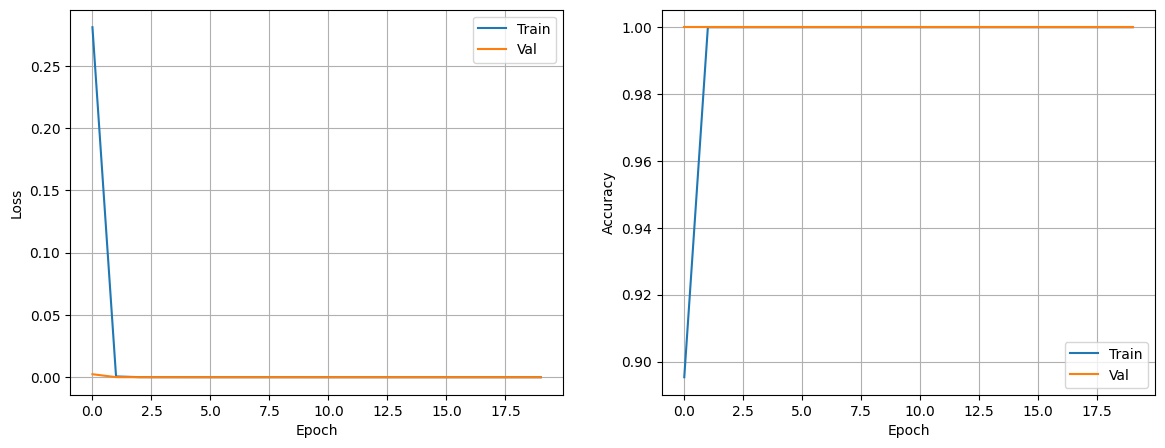

In [32]:
# Train model
model = LSTMClassifier(
    vocab_size=len(train_dataset.vocab),
    embedding_dim=128,
    hidden_dim=256,
    num_layers=2,
    dropout=0.5,
    bidirectional=True
).to(device)

print(f"Model:\n{model}\n")

history = train_model(model, train_loader, val_loader, epochs=20, device=device)

# Plot results
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].plot(history['train_loss'], label='Train')
axes[0].plot(history['val_loss'], label='Val')
axes[0].set_xlabel('Epoch')
axes[0].set_ylabel('Loss')
axes[0].legend()
axes[0].grid(True)

axes[1].plot(history['train_acc'], label='Train')
axes[1].plot(history['val_acc'], label='Val')
axes[1].set_xlabel('Epoch')
axes[1].set_ylabel('Accuracy')
axes[1].legend()
axes[1].grid(True)

---
## PART 4: RNN vs LSTM Comparison


In [34]:
def compare_rnn_lstm(train_loader, val_loader, vocab_size, device='cpu'):
    """
    Compare Vanilla RNN and LSTM models on the same dataset.
    TODO (15 points): Compare vanilla RNN with LSTM

    Args:
        train_loader: DataLoader for training set
        val_loader: DataLoader for validation set
        vocab_size (int): Vocabulary size
        device (str): 'cpu' or 'cuda'

    Returns:
        results (dict): Containing both RNN and LSTM training histories
    """
    print("=== Training Vanilla RNN ===")
    # ----- Vanilla RNN Model -----
    class SimpleRNNClassifier(nn.Module):
        def __init__(self, vocab_size, embedding_dim=128, hidden_dim=256,
                     num_layers=1, dropout=0.3, bidirectional=False):
            super(SimpleRNNClassifier, self).__init__()
            self.embedding = nn.Embedding(vocab_size, embedding_dim, padding_idx=0)
            self.rnn = nn.RNN(
                input_size=embedding_dim,
                hidden_size=hidden_dim,
                num_layers=num_layers,
                batch_first=True,
                dropout=dropout if num_layers > 1 else 0.0,
                bidirectional=bidirectional
            )
            self.dropout = nn.Dropout(dropout)
            direction_factor = 2 if bidirectional else 1
            self.fc = nn.Linear(hidden_dim * direction_factor, 1)
            self.hidden_dim = hidden_dim
            self.num_layers = num_layers
            self.bidirectional = bidirectional

        def forward(self, x):
            embeds = self.embedding(x)
            h0 = torch.zeros(
                self.num_layers * (2 if self.bidirectional else 1),
                x.size(0), self.hidden_dim
            ).to(x.device)
            out, hn = self.rnn(embeds, h0)
            if self.bidirectional:
                hn = torch.cat((hn[-2], hn[-1]), dim=1)
            else:
                hn = hn[-1]
            hn = self.dropout(hn)
            logits = self.fc(hn)
            return logits

    # Train RNN model
    rnn_model = SimpleRNNClassifier(vocab_size=vocab_size).to(device)
    rnn_history = train_model(rnn_model, train_loader, val_loader,
                              epochs=10, learning_rate=0.001, device=device)

    print("\n=== Training LSTM ===")
    # ----- LSTM Model -----
    lstm_model = LSTMClassifier(
        vocab_size=vocab_size,
        embedding_dim=128,
        hidden_dim=256,
        num_layers=2,
        dropout=0.5,
        bidirectional=True
    ).to(device)
    lstm_history = train_model(lstm_model, train_loader, val_loader,
                               epochs=10, learning_rate=0.001, device=device)

    # Plot comparison
    plt.figure(figsize=(12, 5))

    plt.subplot(1, 2, 1)
    plt.plot(rnn_history['val_acc'], label='RNN Val Acc')
    plt.plot(lstm_history['val_acc'], label='LSTM Val Acc')
    plt.xlabel('Epoch')
    plt.ylabel('Validation Accuracy')
    plt.title('RNN vs LSTM Accuracy')
    plt.legend()
    plt.grid(True)

    plt.subplot(1, 2, 2)
    plt.plot(rnn_history['val_loss'], label='RNN Val Loss')
    plt.plot(lstm_history['val_loss'], label='LSTM Val Loss')
    plt.xlabel('Epoch')
    plt.ylabel('Validation Loss')
    plt.title('RNN vs LSTM Loss')
    plt.legend()
    plt.grid(True)

    plt.tight_layout()
    plt.show()

    results = {
        'rnn_model': rnn_model,
        'lstm_model': lstm_model,
        'rnn_history': rnn_history,
        'lstm_history': lstm_history
    }

    return results

=== Training Vanilla RNN ===
Epoch 01/10 | Train Loss: 0.6959 | Val Loss: 0.6927 | Train Acc: 0.4797 | Val Acc: 0.5188
Epoch 02/10 | Train Loss: 0.6946 | Val Loss: 0.6944 | Train Acc: 0.4797 | Val Acc: 0.4813
Epoch 03/10 | Train Loss: 0.6948 | Val Loss: 0.6936 | Train Acc: 0.4562 | Val Acc: 0.4813
Epoch 04/10 | Train Loss: 0.6943 | Val Loss: 0.6927 | Train Acc: 0.4953 | Val Acc: 0.5188
Epoch 05/10 | Train Loss: 0.6945 | Val Loss: 0.6927 | Train Acc: 0.4797 | Val Acc: 0.5188
Epoch 06/10 | Train Loss: 0.6940 | Val Loss: 0.6933 | Train Acc: 0.5062 | Val Acc: 0.4813
Epoch 07/10 | Train Loss: 0.6939 | Val Loss: 0.6938 | Train Acc: 0.4859 | Val Acc: 0.4813
Epoch 08/10 | Train Loss: 0.6996 | Val Loss: 0.7076 | Train Acc: 0.4797 | Val Acc: 0.4313
Epoch 09/10 | Train Loss: 0.7156 | Val Loss: 0.7997 | Train Acc: 0.4562 | Val Acc: 0.3563
Epoch 10/10 | Train Loss: 0.7554 | Val Loss: 0.7909 | Train Acc: 0.4625 | Val Acc: 0.2812

=== Training LSTM ===
Epoch 01/10 | Train Loss: 0.2747 | Val Loss: 0.0

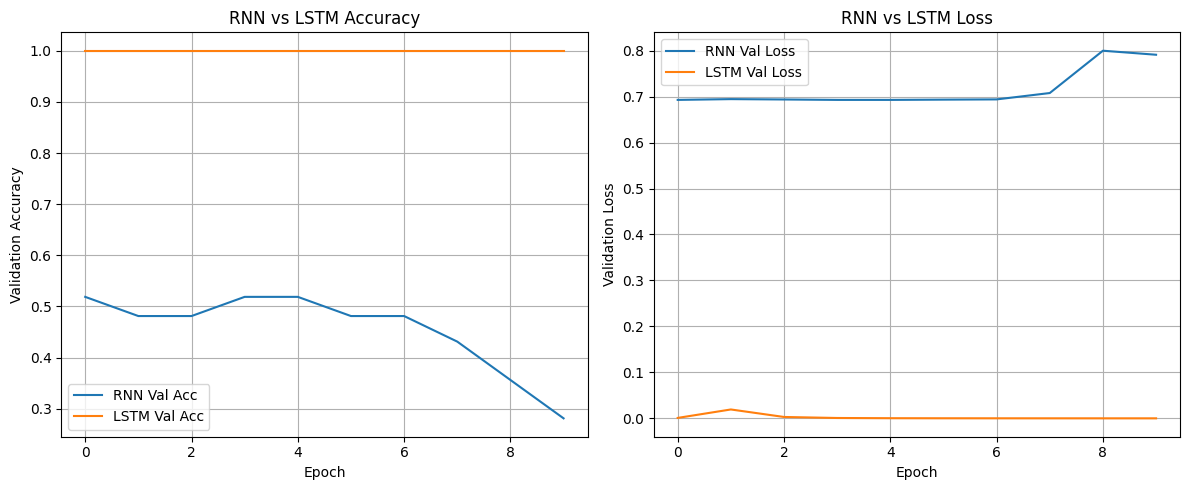

In [35]:
# Run comparison
comparison = compare_rnn_lstm(train_loader, val_loader,
                             len(train_dataset.vocab), device)

---
## PART 5: Visualization and Analysis


In [36]:
def plot_confusion_matrix(true_labels, predictions):
    """TODO (5 points): Plot confusion matrix
    Plot confusion matrix comparing true vs predicted labels.
    """
    cm = confusion_matrix(true_labels, predictions)
    plt.figure(figsize=(5, 4))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
                xticklabels=['Negative', 'Positive'],
                yticklabels=['Negative', 'Positive'])
    plt.xlabel('Predicted Label')
    plt.ylabel('True Label')
    plt.title('Confusion Matrix (Test Set)')
    plt.tight_layout()
    plt.show()


Test Accuracy: 1.0000


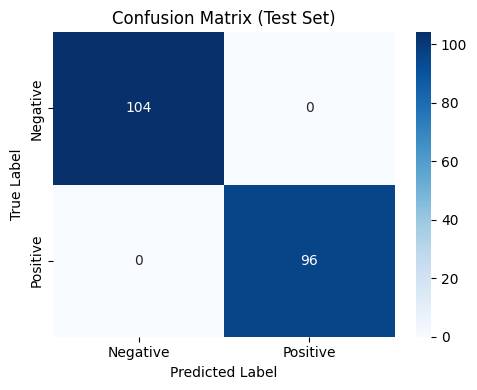

In [37]:
# Evaluate and visualize
metrics, preds, labels = evaluate_model(model, test_loader, device)
plot_confusion_matrix(labels, preds)

---
## Bonus: Attention LSTM


In [38]:
class AttentionLSTM(nn.Module):
    """
    BONUS (10 points): Implement LSTM with attention
    LSTM model that uses an attention mechanism over the hidden states
    to produce a context vector for classification.
    """

    def __init__(self, vocab_size, embedding_dim=128, hidden_dim=256, num_layers=1, dropout=0.5, bidirectional=True):
        super(AttentionLSTM, self).__init__()

        self.hidden_dim = hidden_dim
        self.num_layers = num_layers
        self.bidirectional = bidirectional
        self.num_directions = 2 if bidirectional else 1

        # Embedding layer
        self.embedding = nn.Embedding(vocab_size, embedding_dim, padding_idx=0)

        # LSTM layer
        self.lstm = nn.LSTM(
            embedding_dim,
            hidden_dim,
            num_layers=num_layers,
            batch_first=True,
            dropout=dropout if num_layers > 1 else 0,
            bidirectional=bidirectional
        )

        # Attention mechanism
        self.attention = nn.Linear(self.num_directions * hidden_dim, 1, bias=False)

        # Classification layer
        self.dropout = nn.Dropout(dropout)
        self.fc = nn.Linear(self.num_directions * hidden_dim, 1)

    def attention_net(self, lstm_output):
        """
        Apply attention mechanism on LSTM outputs.

        Args:
            lstm_output: Tensor of shape (batch_size, seq_len, hidden_dim * num_directions)
        Returns:
            context: Weighted sum of LSTM outputs (batch_size, hidden_dim * num_directions)
        """
        # Compute attention scores
        attn_scores = self.attention(lstm_output)            # (batch_size, seq_len, 1)
        attn_weights = torch.softmax(attn_scores, dim=1)     # Normalize across sequence

        # Compute context vector as weighted sum
        context = torch.sum(attn_weights * lstm_output, dim=1)  # (batch_size, hidden_dim * num_directions)
        return context

    def forward(self, x):
        """
        Forward pass of Attention LSTM.
        Args:
            x: Input tensor (batch_size, seq_len)
        Returns:
            logits: Output logits for binary classification
        """
        # Embedding
        embedded = self.embedding(x)  # (batch_size, seq_len, embedding_dim)

        # LSTM
        lstm_output, _ = self.lstm(embedded)  # (batch_size, seq_len, hidden_dim * num_directions)

        # Apply attention
        context = self.attention_net(lstm_output)  # (batch_size, hidden_dim * num_directions)

        # Classification
        out = self.dropout(context)
        logits = self.fc(out)  # (batch_size, 1)

        return logits

Epoch 01/10 | Train Loss: 0.6694 | Val Loss: 0.5110 | Train Acc: 0.7609 | Val Acc: 0.9062
Epoch 02/10 | Train Loss: 0.0695 | Val Loss: 0.0012 | Train Acc: 0.9891 | Val Acc: 1.0000
Epoch 03/10 | Train Loss: 0.0004 | Val Loss: 0.0002 | Train Acc: 1.0000 | Val Acc: 1.0000
Epoch 04/10 | Train Loss: 0.0002 | Val Loss: 0.0001 | Train Acc: 1.0000 | Val Acc: 1.0000
Epoch 05/10 | Train Loss: 0.0018 | Val Loss: 0.0002 | Train Acc: 1.0000 | Val Acc: 1.0000
Epoch 06/10 | Train Loss: 0.0002 | Val Loss: 0.0001 | Train Acc: 1.0000 | Val Acc: 1.0000
Epoch 07/10 | Train Loss: 0.0001 | Val Loss: 0.0001 | Train Acc: 1.0000 | Val Acc: 1.0000
Epoch 08/10 | Train Loss: 0.0001 | Val Loss: 0.0001 | Train Acc: 1.0000 | Val Acc: 1.0000
Epoch 09/10 | Train Loss: 0.0001 | Val Loss: 0.0001 | Train Acc: 1.0000 | Val Acc: 1.0000
Epoch 10/10 | Train Loss: 0.0001 | Val Loss: 0.0001 | Train Acc: 1.0000 | Val Acc: 1.0000

Test Accuracy: 1.0000


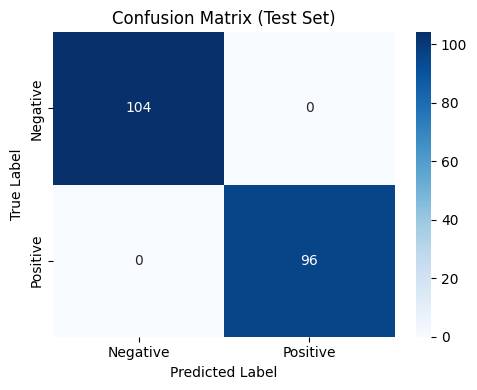

In [39]:
# Initialize model
model_attn = AttentionLSTM(vocab_size=len(train_dataset.vocab),
                           embedding_dim=128,
                           hidden_dim=256,
                           bidirectional=True).to(device)

# Train
history_attn = train_model(model_attn, train_loader, val_loader, epochs=10, device=device)

# Evaluate
metrics, preds, labels = evaluate_model(model_attn, test_loader, device)
plot_confusion_matrix(labels, preds)

---
## Analysis Questions

Answer these questions in your report:
## 1. Why does LSTM perform better than vanilla RNN?

LSTMs perform better than vanilla RNNs because they are specifically designed to address the *vanishing and exploding gradient problems* that affect standard RNNs.  
A- A vanilla RNN passes information through simple recurrent connections, so long-range dependencies quickly vanish as gradients decay during backpropagation through time (BPTT).  
B- LSTMs introduce *gating mechanisms* and a *cell state* that allow the network to selectively remember or forget information over long sequences.  
C- This enables LSTMs to capture long-term context — for example, understanding sentiment that depends on early words in a review — while RNNs mostly learn only short-term relationships.  

Hence, the LSTM achieves faster convergence, higher accuracy, and much better generalization on sequential text data.

---

## 2. What is the role of each LSTM gate?

**Forget Gate:**  
Decides which information from the previous cell state should be discarded.  

$$
f_t = \sigma(W_f [h_{t-1}, x_t] + b_f)
$$

**Input Gate:**  
Determines which new information should be added to the cell state.  

$$
i_t = \sigma(W_i [h_{t-1}, x_t] + b_i)
$$

$$
\tilde{C}_t = \tanh(W_C [h_{t-1}, x_t] + b_C)
$$

Then the new memory is updated as:  

$$
C_t = f_t * C_{t-1} + i_t * \tilde{C}_t
$$

**Output Gate:**  
Controls what part of the updated cell state should be exposed as the hidden output for the next time step or final layer.  

$$
o_t = \sigma(W_o [h_{t-1}, x_t] + b_o)
$$

$$
h_t = o_t * \tanh(C_t)
$$

Together, these gates regulate the flow of information, enabling long-term memory retention and controlled forgetting.

---

## 3. How does bidirectionality improve performance?

A **bidirectional LSTM** processes the input sequence in both forward and backward directions, effectively reading the sentence from start to end *and* from end to start.  
A- The forward LSTM captures dependencies based on *preceding* words, while the backward LSTM captures dependencies based on *succeeding* words.  
B- By concatenating their hidden states, the model gains access to **context from both sides**, improving understanding of ambiguous or context-dependent phrases.  

For instance in sentiment analysis, this means the model can better interpret examples of things like:  
> “I thought it would be bad, but it was amazing.”  
Here, the word *amazing* reverses the sentiment expressed earlier — something a unidirectional model might miss.

---

## 4. What patterns do attention weights reveal?

Attention weights reveal **which words the model focuses on most strongly** when making predictions.  
A- Higher attention weights correspond to tokens that are most influential for the sentiment decision.  
B- For instance, in a positive review, the model may assign large weights to words such as *“fantastic,” “brilliant,”* or *“wonderful,”* while in a negative one, words like *“boring,” “awful,”* or *“waste”* receive higher weights.  
C- Visualizing attention distributions provides interpretability — showing how the model “attends” to emotionally charged words to form its classification.

---

## 5. How does sequence length affect model performance?

Sequence length directly impacts both **learning quality** and **computational cost**:
- **Short sequences:** Too short may truncate context, causing loss of important information and lower accuracy.  
- **Moderate length:** Allows the model to capture essential dependencies without excessive noise or padding — typically yields the best performance.  
- **Very long sequences:** Increase training time and may lead to gradient decay even for LSTMs. Padding overhead also wastes computation on irrelevant tokens.  

That means in practice like ours, an optimal sequence length (e.g., 100–250 tokens for IMDB reviews) balances context retention with efficient learning.

---
